---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 13. Mini CNN Forward Pass

Este  notebook constrói uma versão simplificada de uma rede convolucional completa — da entrada até à geração de probabilidades de saída.  
Partindo das funções desenvolvidas anteriormente, seguimos passo a passo o percurso típico de uma CNN: convolução, ativação ReLU, *max pooling*, achatamento do mapa de características, camada densa e função *softmax*.  
O objetivo é compreender o encadeamento lógico destas operações e observar como a informação visual é progressivamente condensada e transformada em decisões numéricas.  
Apesar de minimalista, esta implementação mostra de forma transparente a estrutura de um *forward pass* completo sem depender de bibliotecas de alto nível.

## 13.1. Recapitulação de funções essenciais

Antes de avançarmos para novas operações sobre imagens, retomamos aqui as funções fundamentais construídas no **Notebook 12**.  
Esta célula garante que todo o código necessário está definido localmente, sem depender da execução anterior.

### Funções incluídas

1. **`convolve2d(image, kernel, stride=1, padding=0)`**  
   Implementa uma convolução 2D elementar entre uma imagem e um kernel:
   - `stride` define o passo de deslocamento do kernel (1 por defeito);  
   - `padding` adiciona margens de zeros para preservar dimensões;  
   - o resultado é uma nova matriz que representa a imagem filtrada.

   Esta implementação, apesar de simples, permite observar diretamente o funcionamento de uma operação fundamental em visão computacional.

2. **`relu(x)`**  
   Aplica a função de ativação **ReLU (Rectified Linear Unit)**, que define:
   \[
   \text{ReLU}(x) = \max(0, x)
   \]
   Esta função introduz não linearidade, truncando respostas negativas e preservando apenas as ativações positivas — comportamento típico das camadas internas de uma CNN.

3. **`show(img, title=None, cmap="gray")`**  
   Pequena função auxiliar de visualização, que apresenta imagens com o mapa de cores definido (por defeito, tons de cinzento), removendo eixos para maior clareza.  
   O parâmetro `title` permite identificar visualmente cada etapa do processamento.

### Objetivo didático

Esta célula serve como ponto de partida para construir, passo a passo, um **mini-pipeline de rede convolucional**:
1. aplicar convoluções com diferentes filtros;  
2. ativar as respostas com ReLU;  
3. reduzir a dimensionalidade com *pooling*;  
4. observar como cada operação contribui para a extração progressiva de padrões visuais.

A ideia central é compreender o encadeamento conceptual das camadas de uma CNN, antes de recorrer a bibliotecas de alto nível como Keras ou PyTorch.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (3,3)

def show(img, title=None, cmap="gray"):
    plt.imshow(img, cmap=cmap)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()
    
def convolve2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode="constant")
    h, w = image.shape
    kh, kw = kernel.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            output[i, j] = np.sum(region * kernel)
    return output

def relu(x):
    return np.maximum(0, x)

## 13.2. Implementação do *Max Pooling* 2D

Após a convolução e a aplicação da função de ativação, é comum reduzir a resolução espacial do mapa de características.  
Esta operação é designada por **pooling**, e tem como principais objetivos:
- Diminuir o número de parâmetros e a carga computacional;  
- Tornar a representação mais robusta a pequenas variações na posição dos padrões (invariância espacial);  
- Destacar apenas as respostas mais fortes em cada região local.

### Função `max_pool2d`

A função implementa o algoritmo de **Max Pooling** sobre um mapa de características 2D (`feature_map`):

1. **Parâmetros**
   - `size`: dimensão da janela de pooling (por defeito, 2×2);  
   - `stride`: passo de deslocamento da janela (por defeito, igual ao tamanho da janela).

2. **Processo**
   - A imagem é percorrida em blocos de `size × size`.  
   - Para cada bloco (`region`), é calculado o valor máximo.  
   - Esse valor é guardado na posição correspondente da saída (`pooled`).

3. **Resultado**
   - O mapa de saída tem dimensões reduzidas:
     $$
     \text{out}_h = \frac{(h - \text{size})}{\text{stride}} + 1
     $$
     
     $$
     \text{out}_w = \frac{(w - \text{size})}{\text{stride}} + 1
     $$
   - Cada valor representa a resposta mais intensa da respetiva região no mapa original.

### Observações didáticas
- O *Max Pooling* atua como uma operação de **subamostragem seletiva**, preservando apenas as ativações dominantes.  
- Se substituirmos `np.max(region)` por `np.mean(region)`, obtemos *Average Pooling*, uma forma mais suave de redução.  
- Alterar `stride` permite controlar a sobreposição das janelas — um *stride* menor cria redundância, enquanto um maior acelera o processamento à custa de perda de detalhe.

O *pooling* é um dos mecanismos que permitem às CNNs **reduzir gradualmente a complexidade espacial**, mantendo informação semântica suficiente para as camadas densas finais.

In [11]:
def max_pool2d(feature_map, size=2, stride=2):
    h, w = feature_map.shape
    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1
    pooled = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            region = feature_map[i*stride:i*stride+size, j*stride:j*stride+size]
            pooled[i, j] = np.max(region)
    return pooled

## 13.3. Criação de um padrão sintético 8×8

Para demonstrar o funcionamento do *pooling*, usamos uma **imagem artificial pequena** — neste caso, uma matriz 8×8.  
A simplicidade e o tamanho reduzido permitem observar facilmente o efeito de cada operação, píxel a píxel.

### Estrutura da imagem

1. Criamos uma matriz de zeros (`np.zeros((8, 8))`), representando uma imagem completamente negra.  
2. Preenchemos o bloco central de linhas 2 a 5 e colunas 3 a 4 com o valor 1.0 — formando um **retângulo branco** no centro.  
3. Visualizamos a imagem com a função `show()`, e imprimimos a sua forma `(8, 8)` para confirmar as dimensões.

### Interpretação didática

Esta pequena grelha funciona como um *toy model* de uma imagem binária, onde:
- `0` representa fundo;  
- `1` representa uma área de interesse (objeto ou ativação).  

Ao aplicar operações de convolução, ReLU e *pooling* a este padrão, torna-se mais fácil compreender como cada etapa transforma a informação espacial.

Esta escolha de tamanho (8×8) é ideal para visualizar reduções de resolução — por exemplo, ao aplicar *pooling* 2×2, a imagem resultante passará a 4×4.

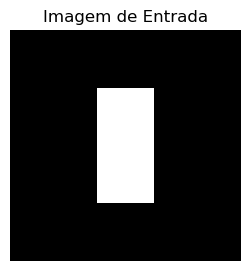

Shape: (8, 8)


In [17]:
img = np.zeros((8, 8))
img[2:6, 3:5] = 1.0
show(img, "Imagem de Entrada")
print("Shape:", img.shape)

## 13.4. Pipeline completo: Convolução → ReLU → Max Pooling

Nesta célula construímos uma sequência de operações equivalente a uma camada convolucional típica de uma CNN.  
Usamos a pequena imagem sintética de 8×8 criada anteriormente e aplicamos três etapas fundamentais.

### 1. Convolução

O **kernel** definido:
\[
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}
\]
atua como um detetor simples de **bordas verticais**.  
As colunas da esquerda têm valores positivos, as da direita negativos — o filtro responde fortemente quando existe uma transição vertical de claro para escuro (ou vice-versa).  

Aplicamos a convolução com `padding=1` para manter as dimensões originais da imagem (`8×8`).

### 2. Função de ativação ReLU

Após a convolução, as respostas negativas são truncadas a zero:
\[
\text{ReLU}(x) = \max(0, x)
\]
Isto simula o comportamento de um neurónio que só “dispara” perante uma ativação positiva — reforçando as bordas numa direção e eliminando as respostas opostas.  
O mapa resultante evidencia apenas as regiões onde o filtro encontra uma correspondência clara com o padrão procurado.

### 3. Max Pooling

Por fim, aplicamos *Max Pooling* 2×2 com passo 2:
- Reduz a resolução de 8×8 para 4×4;  
- Mantém apenas o valor máximo em cada bloco de 2×2;  
- Torna a representação mais compacta e robusta a pequenas deslocações da forma.

### 4. Interpretação dos resultados

1. **Imagem original (8×8):** contém a forma básica (retângulo central).  
2. **Saída da convolução:** mostra a resposta direcional — bordas verticais claras e escuras.  
3. **Após ReLU:** mantém apenas as ativações positivas (bordas numa direção).  
4. **Após Max Pooling:** reduzida a 4×4, preservando apenas as ativações mais fortes.

O resultado final é um **mapa de características condensado**, representando de forma abstrata as estruturas relevantes da imagem inicial.  
Este processo — convolução, ativação e *pooling* — constitui o núcleo funcional das redes convolucionais modernas.

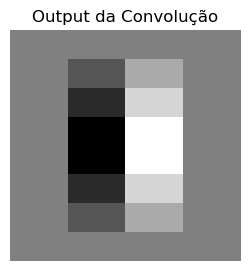

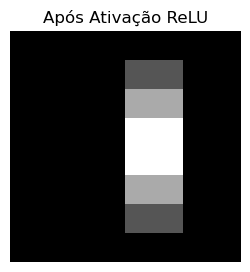

Conv shape: (8, 8)


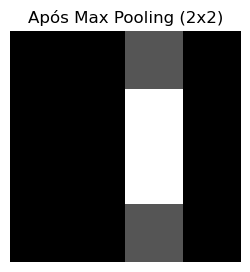

Pooled shape: (4, 4)


In [18]:
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])  # simple edge detector

conv = convolve2d(img, kernel, padding=1)
conv_relu = relu(conv)

show(conv, "Output da Convolução")
show(conv_relu, "Após Ativação ReLU")
print("Conv shape:", conv.shape)
pooled = max_pool2d(conv_relu, size=2, stride=2)
show(pooled, "Após Max Pooling (2x2)")
print("Pooled shape:", pooled.shape)

## 13.5. Camada densa e cálculo de probabilidades (*Softmax*)

Depois da sequência de operações espaciais — convolução, ReLU e *pooling* —, o mapa de características é convertido num vetor e ligado a uma **camada densa** (ou *fully connected*), tal como numa rede neuronal clássica.

### 1. *Flattening*

A função `flatten()` transforma o mapa 2D reduzido (`pooled`) num vetor 1D, concatenando todos os valores.  
Este vetor representa as **características extraídas** pela parte convolucional da rede.

Exemplo:  
Se o mapa tiver dimensão `4×4`, o vetor resultante terá `16` elementos.

### 2. Camada densa (*Fully Connected*)

Criamos uma camada densa fictícia com **4 saídas**, como se estivéssemos a classificar a imagem em quatro categorias.  
- `weights` → matriz de pesos aleatórios de dimensão `4 × n`, onde `n` é o comprimento do vetor achatado;  
- `bias` → vetor de 4 valores (um por classe).

O cálculo da saída é:
$$
y = W \cdot x + b
$$

Este produto escalar combina todas as características extraídas, produzindo quatro valores (logits) que representam a “afinidade” da imagem com cada classe.

### 3. Função Softmax

Os valores brutos da camada densa são convertidos em **probabilidades normalizadas** pela função *softmax*:
$$
\text{softmax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}
$$

A subtração de `np.max(x)` serve apenas para evitar *overflow* numérico.  
O resultado final é um vetor cujos elementos:
- estão entre 0 e 1;  
- somam 1;  
- podem ser interpretados como **probabilidades preditas** por cada classe.

### 4. Interpretação didática

- A operação de *flattening* e *dense layer* liga o espaço visual (padrões convolucionais) ao espaço de decisão (classes).  
- O *softmax* transforma o resultado num formato probabilístico, permitindo uma escolha interpretável.  
- O pipeline completo (Convolução → ReLU → Pooling → Dense → Softmax) representa, em miniatura, o fluxo de informação típico de uma CNN moderna.

Alterar o número de saídas (`weights = np.random.randn(k, len(flattened))`) simula um problema com *k* classes.  
Os valores aleatórios de pesos e *bias* fazem com que as probabilidades não tenham significado real, mas servem para ilustrar todo o processo de classificação.

In [19]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

flattened = pooled.flatten()
print("Comprimento do vetor achatado:", len(flattened))

weights = np.random.randn(4, len(flattened))
bias = np.random.randn(4)

dense_out = np.dot(weights, flattened) + bias
probabilities = softmax(dense_out)

print("Saída bruta da camada densa:", dense_out)
print("Probabilidades Softmax:", probabilities)

Comprimento do vetor achatado: 16
Saída bruta da camada densa: [-0.6551737  -8.80211423  7.83321868  1.01935389]
Probabilidades Softmax: [2.05575772e-04 5.95388738e-08 9.98697356e-01 1.09700858e-03]


## 13.6. Visualização integrada do pipeline

Nesta última célula reunimos, lado a lado, todas as etapas da *mini rede convolucional* construída manualmente.  
O objetivo é observar de forma intuitiva **como a informação se transforma** desde a imagem original até às probabilidades finais de classificação.

### Descrição das subfiguras

1. **Input**  
   A imagem original (8×8), contendo o pequeno padrão sintético criado anteriormente.

2. **Conv + ReLU**  
   Resultado da convolução com o kernel detetor de bordas verticais, seguido da ativação ReLU.  
   Mostra as regiões onde o filtro respondeu fortemente — os “traços” que a rede reconhece.

3. **MaxPool**  
   Resultado do *max pooling* 2×2, que reduz a resolução espacial (de 8×8 para 4×4) e preserva apenas as ativações mais intensas.  
   Este passo compacta a informação mantendo o essencial da forma.

4. **Dense → Softmax**  
   Gráfico de barras que representa as quatro probabilidades de saída obtidas pela camada densa seguida de *softmax*.  
   Cada barra corresponde a uma classe hipotética, e a soma das alturas é igual a 1.

### Interpretação

Este conjunto ilustra, de ponta a ponta, a lógica de uma CNN:
- **extração local** (convolução),  
- **seleção não linear** (ReLU),  
- **redução espacial** (pooling),  
- **decisão global** (camada densa + softmax).

Apesar de simplificada, esta sequência mostra como operações lineares e não lineares se encadeiam para converter padrões visuais em probabilidades de decisão — o princípio fundamental das redes convolucionais modernas.

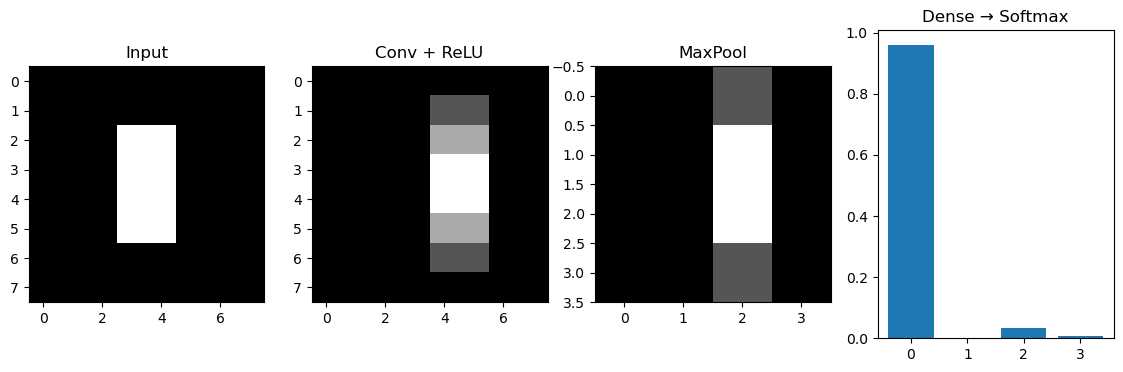

In [16]:
fig, axs = plt.subplots(1, 4, figsize=(14,4))
axs[0].imshow(img, cmap="gray"); axs[0].set_title("Input")
axs[1].imshow(conv_relu, cmap="gray"); axs[1].set_title("Conv + ReLU")
axs[2].imshow(pooled, cmap="gray"); axs[2].set_title("MaxPool")
axs[3].bar(range(4), probabilities); axs[3].set_title("Dense → Softmax")
plt.show()

## 13.7. Conclusão

Neste mini-exemplo implementámos um *forward pass* completo de uma rede convolucional:

1. **Convolução 2D** detecta padrões locais.  
2. **ReLU** elimina valores negativos e introduz não-linearidade.  
3. **Max Pooling** reduz a resolução e foca-se em características dominantes.  
4. **Flatten + Dense + Softmax** transformam o mapa de características numa distribuição de classes.

💡 Em PyTorch, estas operações correspondem a:
```python
nn.Conv2d → nn.ReLU → nn.MaxPool2d → nn.Flatten → nn.Linear → nn.Softmax